# Business Problem
As a Data Analyst, our primary objective is to maximize the return on investment (ROI) for our clients' advertising campaigns. I analyzed Facebook Ads and Google AdWords campaigns to determine which platform delivers better performance in terms of clicks, conversions, and cost-effectiveness. The goal was to provide data-driven insights to optimize budget allocation and maximize ROI.


# Research Question
#### Which ad platform is more effective in terms of conversions, clicks, and overall cost-effectiveness?

# Importing Libraries




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint


# Data Description

The dataset comprises a collection of data comparing the performance of two separate ad campaigns conducted throughout the year 2019. Specifically, the data covers a Facebook Ad campaign and an AdWords Ad campaign. 
For each day of the year 2019, there is a corresponding row in the dataset, resulting in a total of 365 lines of campaign data to analyze. The dataset includes various performance metrics for each ad campaign, providing insights into their effectiveness and efficiency over time.

Key features included in the dataset are as follows:
- Date: The date corresponding to each row of campaign data, ranging from January 1st, 2019, to December 31st, 2019.
- Ad Views: The number of times the ad was viewed.
- Ad Clicks: The number of clicks received on the ad.
- Ad Conversions: The number of conversions resulting from the ad.
- Cost per Ad: The cost associated with running the Facebook ad campaign.
- Click-Through Rate (CTR): The ratio of clicks to views, indicating the effectiveness of the ad in generating clicks.
- Conversion Rate: The ratio of conversions to clicks, reflecting the effectiveness of the ad in driving desired actions.
- Cost per Click (CPC): The average cost incurred per click on the ad.

In [4]:
df = pd.read_csv("marketing_campaign.csv")
print(df.shape)
df.tail()

(365, 17)


,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
360,12/27/2019,FB_Dec19,3240,51,13,$63,1.57%,25.89%,$1.24,AW_Dec19,5332,72,9,$76,1.35%,11.92%,$1.06
361,12/28/2019,FB_Dec19,1510,69,18,$97,4.55%,25.82%,$1.42,AW_Dec19,3887,49,6,$121,1.27%,13.10%,$2.46
362,12/29/2019,FB_Dec19,2918,44,13,$49,1.50%,29.11%,$1.11,AW_Dec19,5327,62,6,$128,1.16%,9.85%,$2.08
363,12/30/2019,FB_Dec19,2212,37,8,$102,1.68%,22.70%,$2.75,AW_Dec19,4020,71,6,$119,1.76%,7.83%,$1.68
364,12/31/2019,FB_Dec19,1470,60,17,$99,4.06%,28.38%,$1.65,AW_Dec19,4592,47,6,$86,1.01%,13.60%,$1.85


In [10]:
df.dtypes

Date                                               datetime64[us]
Facebook Ad Campaign                                          str
Facebook Ad Views                                           int64
Facebook Ad Clicks                                          int64
Facebook Ad Conversions                                     int64
Cost per Facebook Ad                                          str
Facebook Click-Through Rate (Clicks / View)                   str
Facebook Conversion Rate (Conversions / Clicks)               str
Facebook Cost per Click (Ad Cost / Clicks)                    str
AdWords Ad Campaign                                           str
AdWords Ad Views                                            int64
AdWords Ad Clicks                                           int64
AdWords Ad Conversions                                      int64
Cost per AdWords Ad                                           str
AdWords Click-Through Rate (Clicks / View)                    str
AdWords Co

In [9]:
df["Date"]= pd.to_datetime(df["Date"])

In [11]:
df.describe()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions
count,365,365.000000,365.000000,365.000000,365.00000,365.000000,365.000000
mean,2019-07-02 00:00:00,2179.687671,44.049315,11.742466,4717.19726,60.383562,5.980822
min,2019-01-01 00:00:00,1050.000000,15.000000,5.000000,3714.00000,31.000000,3.000000
25%,2019-04-02 00:00:00,1656.000000,35.000000,10.000000,4247.00000,49.000000,5.000000
50%,2019-07-02 00:00:00,2202.000000,43.000000,12.000000,4711.00000,60.000000,6.000000
75%,2019-10-01 00:00:00,2717.000000,54.000000,13.000000,5190.00000,73.000000,7.000000
max,2019-12-31 00:00:00,3320.000000,73.000000,19.000000,5760.00000,89.000000,9.000000
std,NaN,618.074639,12.140559,2.924786,561.11406,14.368225,1.628106


<Axes: xlabel='AdWords Ad Clicks', ylabel='Count'>

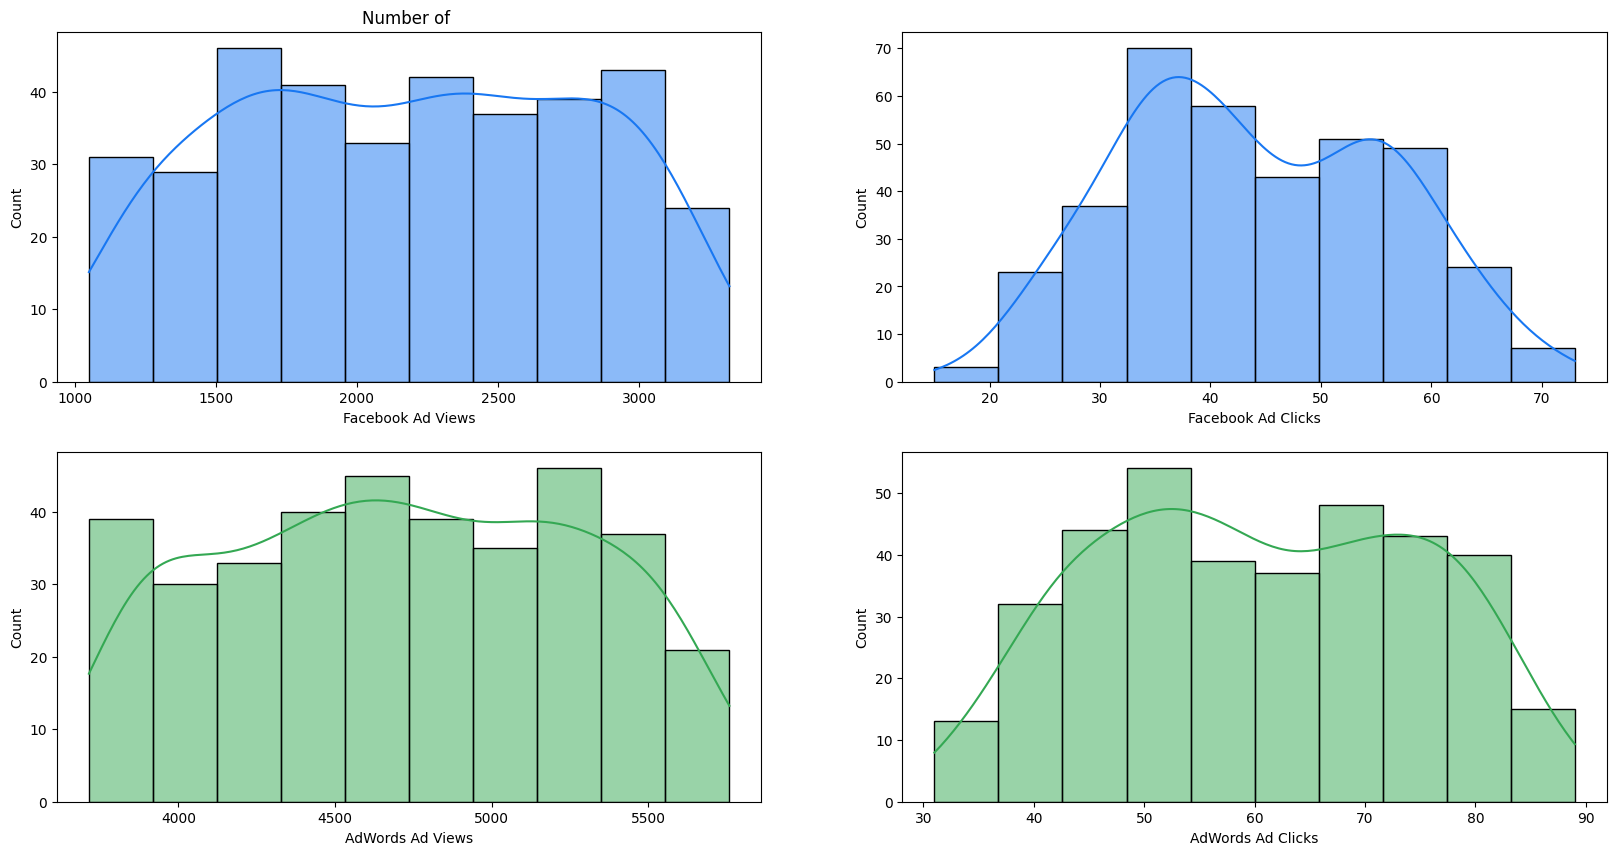

In [ ]:
# countplot plots for Facebook click and conversion
plt.figure(figsize=(20,10))
plt.subplot(2,2,1)
sns.histplot(df["Facebook Ad Views"],bins= 10,edgecolor ='k', kde= True,color="#1877F2")
plt.title("Number of views on Facebook")
plt.subplot(2,2,2)
sns.histplot(df["Facebook Ad Clicks"],bins= 10,edgecolor ='k', kde= True,color="#1877F2")
plt.title("Number of Clicks on Facebook")

plt.subplot(2,2,3)
sns.histplot(df["AdWords Ad Views"],bins =10,edgecolor ='k', kde= True,color="#34A853")
plt.title("Number of views on Adwords")

plt.subplot(2,2,4)
sns.histplot(df["AdWords Ad Clicks"],bins =10,edgecolor ='k', kde= True,color="#34A853")
plt.title("Number of clicks on Adwords")